# Retail Auto-Scrape, Clean, and Model Notebook

A Colab/Jupyter workflow that automatically acquires a public retail dataset, cleans it, performs EDA, and trains a baseline sales model with reusable outputs.

This notebook is designed to run in either Google Colab or a local Jupyter environment. If the public download is unavailable, it falls back to a synthetic retail dataset so the workflow still executes end to end.

In [24]:
# Optional installs for Colab. Uncomment if the environment is missing dependencies.
# %pip install pandas numpy matplotlib seaborn scikit-learn requests beautifulsoup4 openpyxl joblib

from __future__ import annotations

from io import BytesIO
from pathlib import Path
from urllib.parse import urljoin, urlparse

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import seaborn as sns
from bs4 import BeautifulSoup
from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

sns.set_theme(style="whitegrid", context="talk")

WORKSPACE_ROOT = Path("/content") if Path("/content").exists() else Path.cwd()
OUTPUT_DIR = WORKSPACE_ROOT / "outputs"
PLOTS_DIR = OUTPUT_DIR / "plots"
MODELS_DIR = OUTPUT_DIR / "models"
for folder in [OUTPUT_DIR, PLOTS_DIR, MODELS_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
HEADERS = {"User-Agent": "Mozilla/5.0"}
TIMEOUT = 30

## 1. Set Up Colab/Jupyter Environment

The notebook is built to work in Colab or local Jupyter. It installs or imports the libraries needed for dataset acquisition, cleaning, visualization, and modeling.

## 2. Define Dataset Sources and Scraping Strategy

The notebook first tries the UCI Online Retail dataset, then scrapes HTML landing pages for downloadable files if needed. If every network route fails, it generates a realistic synthetic retail dataset so the rest of the workflow still runs.

In [25]:
DATA_SOURCES = [
    {
        "name": "UCI Online Retail file",
        "url": "https://archive.ics.uci.edu/ml/machine-learning-databases/00352/Online%20Retail.xlsx",
        "kind": "binary",
    },
    {
        "name": "UCI Online Retail landing page",
        "url": "https://archive.ics.uci.edu/dataset/352/online+retail",
        "kind": "html",
    },
]

CATEGORY_RULES = {
    "Electronics": ["laptop", "computer", "usb", "wireless", "headphone", "monitor", "camera", "keyboard", "mouse", "speaker", "charger", "phone", "tablet"],
    "Home": ["candle", "lamp", "chair", "table", "storage", "kitchen", "bath", "towel", "mug", "plate", "frame", "mirror", "cushion"],
    "Office": ["paper", "pen", "notebook", "folder", "binder", "calculator", "printer", "desk", "staple"],
    "Apparel": ["shirt", "jeans", "jacket", "shoe", "sneaker", "dress", "skirt", "coat", "sock"],
    "Beauty": ["cream", "soap", "shampoo", "lotion", "makeup", "perfume", "skincare", "face wash"],
    "Grocery": ["tea", "coffee", "snack", "cereal", "bread", "rice", "pasta", "sugar"],
}


def normalize_name(value: str) -> str:
    text = str(value).strip().lower()
    text = "".join(ch if ch.isalnum() else "_" for ch in text)
    while "__" in text:
        text = text.replace("__", "_")
    return text.strip("_")


def discover_file_links(page_url: str, extensions: tuple[str, ...] = (".csv", ".xlsx", ".xls", ".json", ".txt")) -> list[str]:
    response = requests.get(page_url, headers=HEADERS, timeout=TIMEOUT)
    response.raise_for_status()
    soup = BeautifulSoup(response.text, "html.parser")
    discovered = []
    for anchor in soup.select("a[href]"):
        href = urljoin(page_url, anchor.get("href"))
        href_lower = href.lower()
        if any(href_lower.endswith(extension) for extension in extensions):
            discovered.append(href)
    unique_links = []
    seen = set()
    for link in discovered:
        if link not in seen:
            seen.add(link)
            unique_links.append(link)
    return unique_links


def download_bytes(url: str) -> tuple[bytes, str]:
    response = requests.get(url, headers=HEADERS, timeout=TIMEOUT)
    response.raise_for_status()
    file_name = Path(urlparse(response.url).path).name or Path(urlparse(url).path).name or "downloaded_file"
    return response.content, file_name


def read_any_dataset(file_bytes: bytes, file_name: str) -> pd.DataFrame:
    suffix = Path(file_name).suffix.lower()
    if suffix in {".xlsx", ".xls"}:
        return pd.read_excel(BytesIO(file_bytes))
    if suffix == ".json":
        return pd.read_json(BytesIO(file_bytes))
    if suffix == ".txt":
        return pd.read_csv(BytesIO(file_bytes), sep=None, engine="python")
    return pd.read_csv(BytesIO(file_bytes), sep=None, engine="python")


def infer_category(description: str) -> str:
    if pd.isna(description):
        return "Other"
    text = str(description).lower()
    for category, keywords in CATEGORY_RULES.items():
        if any(keyword in text for keyword in keywords):
            return category
    return "Other"


def make_synthetic_retail_data(rows: int = 1500, seed: int = RANDOM_STATE) -> pd.DataFrame:
    rng = np.random.default_rng(seed)
    catalog = {
        "Electronics": [("Laptop", 800, 2200), ("Smartphone", 350, 1200), ("Headphones", 40, 350), ("Monitor", 120, 600)],
        "Home": [("Desk Lamp", 25, 140), ("Office Chair", 70, 420), ("Bookshelf", 60, 260), ("Table Organizer", 12, 80)],
        "Grocery": [("Coffee", 4, 18), ("Cereal", 3, 15), ("Snack Box", 5, 22), ("Tea", 3, 16)],
        "Apparel": [("T-Shirt", 10, 45), ("Jeans", 20, 110), ("Jacket", 35, 220), ("Sneakers", 45, 180)],
        "Beauty": [("Shampoo", 6, 28), ("Skin Cream", 12, 80), ("Perfume", 18, 160), ("Face Wash", 5, 24)],
    }
    flattened = []
    for category, items in catalog.items():
        for product, low, high in items:
            flattened.append({"category": category, "product": product, "low": low, "high": high})
    product_frame = pd.DataFrame(flattened)

    chosen = product_frame.sample(n=rows, replace=True, random_state=seed).reset_index(drop=True)
    invoice_dates = pd.Timestamp("2024-01-01") + pd.to_timedelta(rng.integers(0, 730, size=rows), unit="D")
    quantity = np.clip(rng.poisson(lam=2.5, size=rows) + 1, 1, 12)
    unit_price = np.array([rng.uniform(low, high) for low, high in zip(chosen["low"], chosen["high"])])
    discount = rng.uniform(0.0, 0.30, size=rows)
    sales = quantity * unit_price * (1 - discount)

    demo = pd.DataFrame(
        {
            "invoice_no": [f"O{i:06d}" for i in range(1, rows + 1)],
            "stock_code": [f"S{rng.integers(1000, 9999)}" for _ in range(rows)],
            "description": chosen["product"].to_numpy(),
            "quantity": quantity.astype(float),
            "invoice_date": invoice_dates,
            "unit_price": unit_price,
            "customer_id": [f"C{rng.integers(1, 800):04d}" for _ in range(rows)],
            "country": rng.choice(["North", "South", "East", "West", "Central"], size=rows),
            "sales": sales,
        }
    )

    missing_idx = rng.choice(demo.index, size=max(1, rows // 25), replace=False)
    demo.loc[missing_idx[: len(missing_idx) // 4], "quantity"] = np.nan
    demo.loc[missing_idx[len(missing_idx) // 4 : len(missing_idx) // 2], "unit_price"] = np.nan
    demo.loc[missing_idx[len(missing_idx) // 2 : (3 * len(missing_idx)) // 4], "country"] = pd.NA
    demo.loc[missing_idx[(3 * len(missing_idx)) // 4 :], "invoice_date"] = pd.NaT

    duplicate_rows = demo.sample(frac=0.02, random_state=seed)
    demo = pd.concat([demo, duplicate_rows], ignore_index=True)
    return demo


def load_public_retail_dataset() -> tuple[pd.DataFrame, str]:
    for source in DATA_SOURCES:
        try:
            if source["kind"] == "binary":
                file_bytes, file_name = download_bytes(source["url"])
                return read_any_dataset(file_bytes, file_name), source["name"]
            discovered_links = discover_file_links(source["url"])
            if discovered_links:
                file_bytes, file_name = download_bytes(discovered_links[0])
                return read_any_dataset(file_bytes, file_name), f"{source['name']} -> {discovered_links[0]}"
        except Exception:
            continue
    fallback = make_synthetic_retail_data()
    return fallback, "Synthetic fallback retail data"

## 3. Fetch and Download Datasets Automatically

This section executes the download strategy, reports which source succeeded, and materializes the raw dataset for downstream parsing.

In [26]:
raw_df, source_label = load_public_retail_dataset()
print(f"Loaded dataset source: {source_label}")
print(f"Raw shape: {raw_df.shape}")
raw_df.head()

Loaded dataset source: Synthetic fallback retail data
Raw shape: (1530, 9)


,invoice_no,stock_code,description,quantity,invoice_date,unit_price,customer_id,country,sales
0,O000001,S7728,Bookshelf,3.0,2024-03-06,114.513718,C0326,West,282.219638
1,O000002,S4650,Face Wash,3.0,2025-07-18,10.018673,C0667,East,24.121213
2,O000003,S8050,Jacket,3.0,2025-04-22,144.998451,C0423,South,325.954870
3,O000004,S4881,Snack Box,3.0,2024-11-16,18.564880,C0061,South,52.251188
4,O000005,S9730,Table Organizer,1.0,2024-11-12,64.848205,C0685,West,47.774293


## 4. Parse Files and Build a Unified DataFrame

The raw dataset is standardized into a common retail schema so the notebook can handle public retail files or the synthetic fallback with the same downstream logic.

In [27]:
COLUMN_ALIASES = {
    "date": ["invoice_date", "order_date", "transaction_date", "date", "timestamp"],
    "sales": ["sales", "revenue", "amount"],
    "quantity": ["quantity", "qty", "units"],
    "price": ["unit_price", "price", "selling_price", "sale_price"],
    "product": ["description", "product", "item", "product_name"],
    "region": ["country", "region", "market", "state", "city"],
    "customer_id": ["customer_id", "customerid", "client_id"],
    "order_id": ["invoice_no", "order_id", "transaction_id", "order_number"],
    "category": ["category", "product_category", "segment"],
}


def coerce_numeric(series: pd.Series) -> pd.Series:
    if pd.api.types.is_numeric_dtype(series):
        return pd.to_numeric(series, errors="coerce")
    text = series.astype("string").str.replace(r"[,$]", "", regex=True).str.replace(r"\(([^)]+)\)", r"-\1", regex=True)
    text = text.str.replace(r"[^0-9.\-]", "", regex=True)
    text = text.replace({"": pd.NA, "-": pd.NA, ".": pd.NA, "-.": pd.NA})
    return pd.to_numeric(text, errors="coerce")


def standardize_retail_schema(df: pd.DataFrame) -> pd.DataFrame:
    working = df.copy()
    working.columns = [normalize_name(column) for column in working.columns]

    rename_map = {}
    for canonical_name, aliases in COLUMN_ALIASES.items():
        for alias in [canonical_name, *aliases]:
            if alias in working.columns:
                rename_map[alias] = canonical_name
                break
    working = working.rename(columns=rename_map)

    for column in working.select_dtypes(include=["object", "string", "category"]).columns:
        working[column] = working[column].astype("string").str.strip()

    for column in ["quantity", "price", "sales"]:
        if column in working.columns:
            working[column] = coerce_numeric(working[column])

    if "date" in working.columns:
        working["date"] = pd.to_datetime(working["date"], errors="coerce")
    elif "invoice_date" in working.columns:
        working["date"] = pd.to_datetime(working["invoice_date"], errors="coerce")

    if "sales" not in working.columns and {"quantity", "price"}.issubset(working.columns):
        working["sales"] = working["quantity"] * working["price"]
    elif "sales" in working.columns and {"quantity", "price"}.issubset(working.columns):
        sales_mask = working["sales"].isna() & working["quantity"].notna() & working["price"].notna()
        working.loc[sales_mask, "sales"] = working.loc[sales_mask, "quantity"] * working.loc[sales_mask, "price"]

    if "product" in working.columns and "category" not in working.columns:
        working["category"] = working["product"].map(infer_category)
    elif "category" in working.columns:
        working["category"] = working["category"].fillna("Other")

    if "region" not in working.columns and "country" in working.columns:
        working["region"] = working["country"]

    if "customer_id" not in working.columns:
        working["customer_id"] = "Unknown"
    if "order_id" not in working.columns:
        working["order_id"] = np.arange(1, len(working) + 1)

    working["date"] = working.get("date", pd.NaT)
    working["month"] = working["date"].dt.month
    working["day_of_week"] = working["date"].dt.dayofweek
    working["hour"] = working["date"].dt.hour
    working["is_weekend"] = working["day_of_week"].isin([5, 6]).astype(int)
    return working


retail_df = standardize_retail_schema(raw_df)
print(f"Unified shape: {retail_df.shape}")
retail_df.head()

Unified shape: (1530, 14)


,order_id,stock_code,product,quantity,date,price,customer_id,region,sales,category,month,day_of_week,hour,is_weekend
0,O000001,S7728,Bookshelf,3.0,2024-03-06,114.513718,C0326,West,282.219638,Other,3.0,2.0,0.0,0
1,O000002,S4650,Face Wash,3.0,2025-07-18,10.018673,C0667,East,24.121213,Beauty,7.0,4.0,0.0,0
2,O000003,S8050,Jacket,3.0,2025-04-22,144.998451,C0423,South,325.954870,Apparel,4.0,1.0,0.0,0
3,O000004,S4881,Snack Box,3.0,2024-11-16,18.564880,C0061,South,52.251188,Grocery,11.0,5.0,0.0,1
4,O000005,S9730,Table Organizer,1.0,2024-11-12,64.848205,C0685,West,47.774293,Home,11.0,1.0,0.0,0


## 5. Profile Data Types and Missing Values

This section inspects the cleaned-but-not-yet-imputed retail table so the notebook can report data quality issues before imputation and deduplication.

In [28]:
profile_rows = []
for column in retail_df.columns:
    profile_rows.append(
        {
            "column": column,
            "dtype": str(retail_df[column].dtype),
            "missing": int(retail_df[column].isna().sum()),
            "unique_values": int(retail_df[column].nunique(dropna=True)),
        }
    )

profile_df = pd.DataFrame(profile_rows).sort_values(by="missing", ascending=False)
duplicate_count = int(retail_df.duplicated().sum())
print(f"Rows: {len(retail_df):,}")
print(f"Columns: {retail_df.shape[1]:,}")
print(f"Duplicates: {duplicate_count:,}")
profile_df.head(10)

Rows: 1,530
Columns: 14
Duplicates: 30


,column,dtype,missing,unique_values
4,date,datetime64[ns],16,633
7,region,string,16,5
10,month,float64,16,12
11,day_of_week,float64,16,7
12,hour,float64,16,1
3,quantity,float64,15,10
5,price,float64,15,1485
2,product,string,0,20
0,order_id,string,0,1500
1,stock_code,string,0,1364


## 6. Clean, Normalize, and Deduplicate Data

Here the notebook removes duplicate rows, fills missing values with sensible defaults, normalizes text fields, and filters invalid transactions so the downstream model is trained on a cleaner retail table.

In [6]:
def fill_mode(series: pd.Series, default_value: str = "Unknown") -> pd.Series:
    mode_values = series.mode(dropna=True)
    if mode_values.empty:
        return series.fillna(default_value)
    return series.fillna(mode_values.iloc[0])


cleaned_df = retail_df.copy()
cleaned_df = cleaned_df.drop_duplicates().reset_index(drop=True)

for column in cleaned_df.select_dtypes(include=["object", "string"]).columns:
    cleaned_df[column] = cleaned_df[column].astype("string").str.strip().replace({"": pd.NA, "nan": pd.NA, "None": pd.NA})

for column in ["category", "product", "region"]:
    if column in cleaned_df.columns:
        cleaned_df[column] = cleaned_df[column].astype("string").str.title()

for column in ["quantity", "price", "sales"]:
    if column in cleaned_df.columns:
        cleaned_df[column] = pd.to_numeric(cleaned_df[column], errors="coerce")
        cleaned_df.loc[cleaned_df[column] < 0, column] = pd.NA

if "date" in cleaned_df.columns:
    cleaned_df["date"] = pd.to_datetime(cleaned_df["date"], errors="coerce")

numeric_columns = cleaned_df.select_dtypes(include=[np.number]).columns.tolist()
categorical_columns = [column for column in cleaned_df.columns if column not in numeric_columns and column != "date"]

for column in numeric_columns:
    cleaned_df[column] = cleaned_df[column].fillna(cleaned_df[column].median())
for column in categorical_columns:
    cleaned_df[column] = fill_mode(cleaned_df[column])
if "date" in cleaned_df.columns:
    cleaned_df["date"] = cleaned_df["date"].fillna(cleaned_df["date"].median())

cleaned_df = cleaned_df.loc[(cleaned_df["quantity"] > 0) & (cleaned_df["price"] > 0)].copy()
cleaned_df["sales"] = cleaned_df["quantity"] * cleaned_df["price"] if "sales" not in cleaned_df.columns else cleaned_df["sales"].fillna(cleaned_df["quantity"] * cleaned_df["price"])

cleaned_df["month"] = cleaned_df["date"].dt.month
cleaned_df["day_of_week"] = cleaned_df["date"].dt.dayofweek
cleaned_df["hour"] = cleaned_df["date"].dt.hour
cleaned_df["is_weekend"] = cleaned_df["day_of_week"].isin([5, 6]).astype(int)
cleaned_df["customer_purchase_count"] = cleaned_df.groupby("customer_id")["customer_id"].transform("size")

cleaned_path = OUTPUT_DIR / "cleaned_retail_data.csv"
cleaned_df.to_csv(cleaned_path, index=False)
print(f"Saved cleaned dataset to: {cleaned_path}")
print(f"Cleaned shape: {cleaned_df.shape}")
cleaned_df.head()

Saved cleaned dataset to: e:\NYERAS\outputs\cleaned_retail_data.csv
Cleaned shape: (1500, 15)


,order_id,stock_code,product,quantity,date,price,customer_id,region,sales,category,month,day_of_week,hour,is_weekend,customer_purchase_count
0,O000001,S7728,Bookshelf,3.0,2024-03-06,114.513718,C0326,West,282.219638,Other,3,2,0,0,2
1,O000002,S4650,Face Wash,3.0,2025-07-18,10.018673,C0667,East,24.121213,Beauty,7,4,0,0,1
2,O000003,S8050,Jacket,3.0,2025-04-22,144.998451,C0423,South,325.954870,Apparel,4,1,0,0,4
3,O000004,S4881,Snack Box,3.0,2024-11-16,18.564880,C0061,South,52.251188,Grocery,11,5,0,1,2
4,O000005,S9730,Table Organizer,1.0,2024-11-12,64.848205,C0685,West,47.774293,Home,11,1,0,0,4


## Exploratory Data Analysis

These charts summarize the cleaned retail data and show the key business relationships requested in the project brief: distributions, product/category performance, regional revenue, and sales trends over time.

In [29]:
# Signature block for plot attribution and notebook reuse
AUTHOR_NAME = "Nagabhushana Raju S"
AUTHOR_HASH = bytes.fromhex("4e6167616268757368616e6152616a7553").decode("utf-8")
SIGNATURE_BANNER = f"{AUTHOR_NAME} | {AUTHOR_HASH}"


def apply_matplotlib_signature(fig, text: str = SIGNATURE_BANNER, *, alpha: float = 0.18, fontsize: int = 24):
    fig.text(
        0.5,
        0.5,
        text,
        ha="center",
        va="center",
        rotation=30,
        fontsize=fontsize,
        color="gray",
        alpha=alpha,
        transform=fig.transFigure,
    )
    return fig


def apply_plotly_signature(fig, text: str = SIGNATURE_BANNER, *, opacity: float = 0.18, fontsize: int = 18):
    fig.add_annotation(
        text=text,
        xref="paper",
        yref="paper",
        x=0.5,
        y=0.5,
        showarrow=False,
        opacity=opacity,
        font=dict(size=fontsize, color="gray"),
    )
    return fig

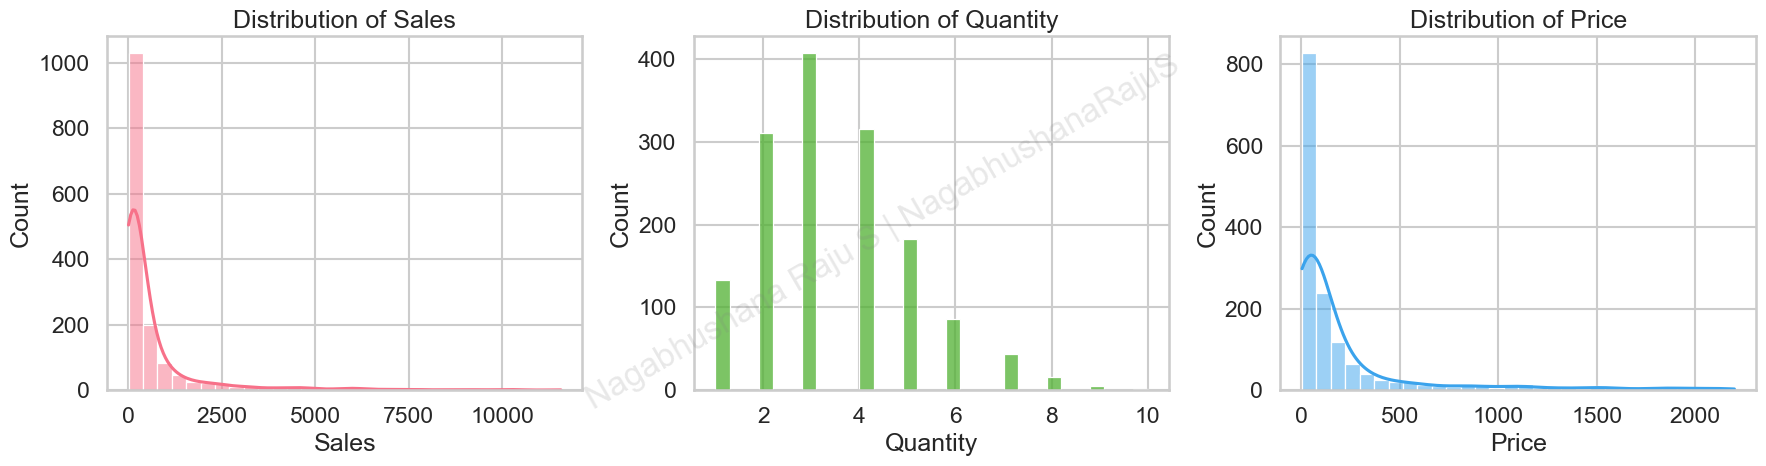

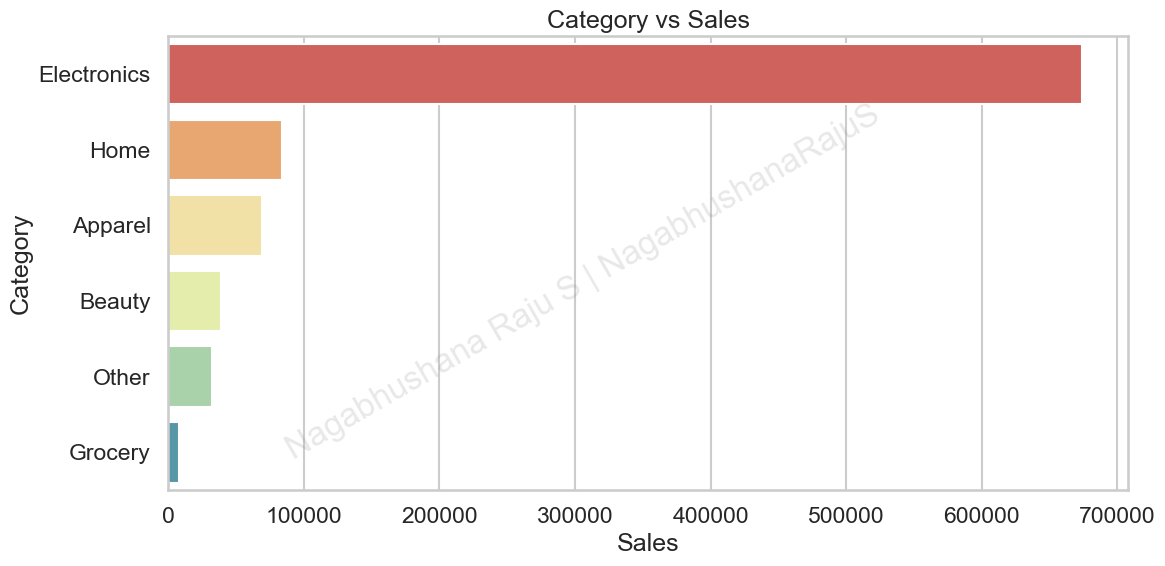

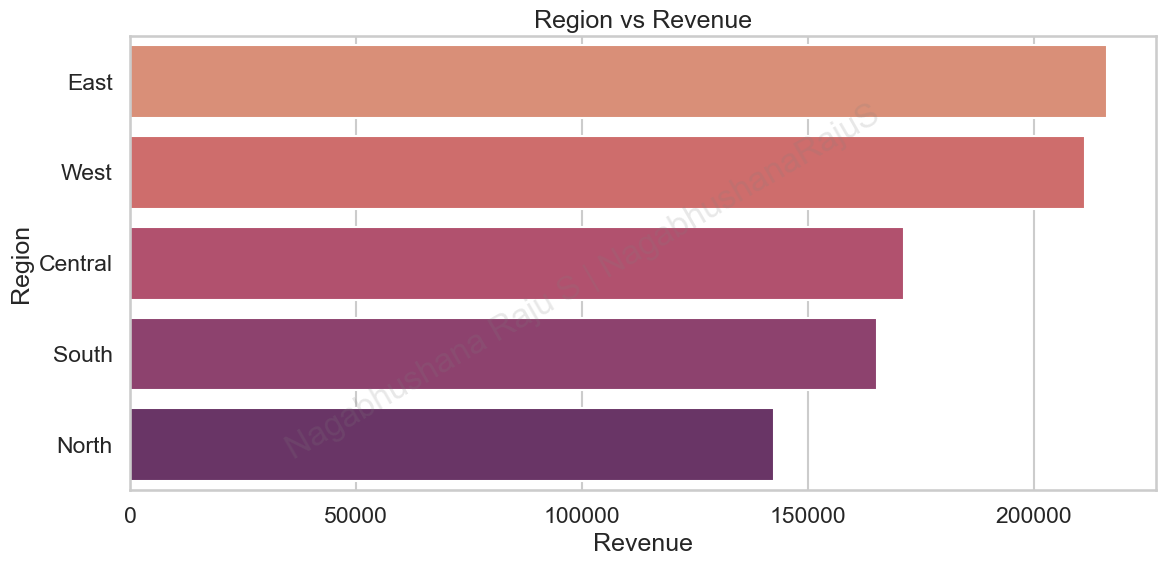

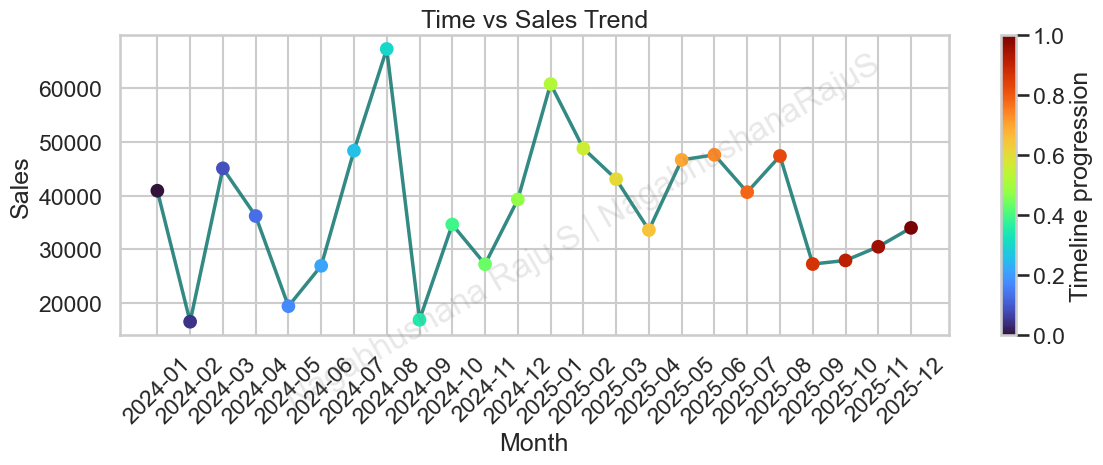

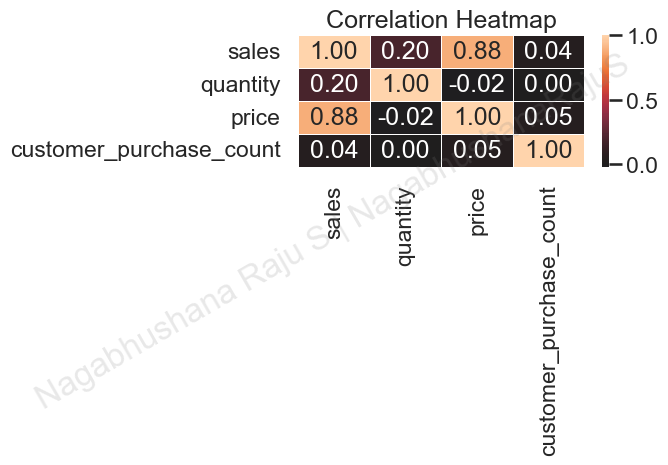

In [30]:
# Signature: Nagabhushana Raju S
eda_df = cleaned_df.copy()

numeric_targets = [column for column in ["sales", "quantity", "price"] if column in eda_df.columns]
fig, axes = plt.subplots(1, len(numeric_targets), figsize=(6 * len(numeric_targets), 5))
if len(numeric_targets) == 1:
    axes = [axes]

numeric_colors = sns.color_palette("husl", len(numeric_targets)) if numeric_targets else []
for axis, column, color in zip(axes, numeric_targets, numeric_colors):
    sns.histplot(
        eda_df[column],
        bins=30,
        kde=eda_df[column].nunique() > 10,
        color=color,
        ax=axis,
    )
    axis.set_title(f"Distribution of {column.title()}")
    axis.set_xlabel(column.title())
    axis.set_ylabel("Count")

apply_matplotlib_signature(fig)
fig.tight_layout()
fig.savefig(PLOTS_DIR / "01_numeric_distributions.png", dpi=300, bbox_inches="tight")
plt.show()

group_column = "category" if "category" in eda_df.columns else "product"
if group_column in eda_df.columns and "sales" in eda_df.columns:
    top_group_sales = eda_df.groupby(group_column, dropna=False)["sales"].sum().sort_values(ascending=False).head(10).reset_index()
    fig, ax = plt.subplots(figsize=(12, max(6, 0.5 * len(top_group_sales) + 2)))
    group_palette = sns.color_palette("Spectral", len(top_group_sales))
    sns.barplot(
        data=top_group_sales,
        y=group_column,
        x="sales",
        hue=group_column,
        palette=group_palette,
        dodge=False,
        legend=False,
        ax=ax,
    )
    ax.set_title(f"{group_column.title()} vs Sales")
    ax.set_xlabel("Sales")
    ax.set_ylabel(group_column.title())
    apply_matplotlib_signature(fig)
    fig.tight_layout()
    fig.savefig(PLOTS_DIR / "02_category_vs_sales.png", dpi=300, bbox_inches="tight")
    plt.show()

if "region" in eda_df.columns and "sales" in eda_df.columns:
    top_regions = eda_df.groupby("region", dropna=False)["sales"].sum().sort_values(ascending=False).head(10).reset_index()
    fig, ax = plt.subplots(figsize=(12, max(6, 0.5 * len(top_regions) + 2)))
    region_palette = sns.color_palette("flare", len(top_regions))
    sns.barplot(
        data=top_regions,
        y="region",
        x="sales",
        hue="region",
        palette=region_palette,
        dodge=False,
        legend=False,
        ax=ax,
    )
    ax.set_title("Region vs Revenue")
    ax.set_xlabel("Revenue")
    ax.set_ylabel("Region")
    apply_matplotlib_signature(fig)
    fig.tight_layout()
    fig.savefig(PLOTS_DIR / "03_region_vs_revenue.png", dpi=300, bbox_inches="tight")
    plt.show()

if "date" in eda_df.columns and "sales" in eda_df.columns:
    sales_trend = eda_df.dropna(subset=["date"]).assign(month_period=eda_df["date"].dt.to_period("M")).groupby("month_period")["sales"].sum().reset_index()
    fig, ax = plt.subplots(figsize=(12, 5))
    month_labels = sales_trend["month_period"].astype(str)
    trend_colors = np.linspace(0, 1, len(sales_trend))
    ax.plot(month_labels, sales_trend["sales"], color="#0f766e", linewidth=2.5, alpha=0.85)
    scatter = ax.scatter(month_labels, sales_trend["sales"], c=trend_colors, cmap="turbo", s=70, zorder=3)
    fig.colorbar(scatter, ax=ax, label="Timeline progression")
    ax.set_title("Time vs Sales Trend")
    ax.set_xlabel("Month")
    ax.set_ylabel("Sales")
    ax.tick_params(axis="x", rotation=45)
    apply_matplotlib_signature(fig)
    fig.tight_layout()
    fig.savefig(PLOTS_DIR / "04_time_sales_trend.png", dpi=300, bbox_inches="tight")
    plt.show()

correlation_columns = [column for column in ["sales", "quantity", "price", "customer_purchase_count"] if column in eda_df.columns]
if len(correlation_columns) >= 2:
    corr = eda_df[correlation_columns].corr(numeric_only=True)
    fig, ax = plt.subplots(figsize=(7, 5))
    sns.heatmap(corr, annot=True, cmap="icefire", center=0, linewidths=0.5, ax=ax, fmt=".2f")
    ax.set_title("Correlation Heatmap")
    apply_matplotlib_signature(fig)
    fig.tight_layout()
    fig.savefig(PLOTS_DIR / "05_correlation_heatmap.png", dpi=300, bbox_inches="tight")
    plt.show()

## 7. Feature Engineering for Modeling

This section turns the cleaned retail table into a modeling-ready matrix, adds time-based and behavioral features, and keeps the target definition explicit so the notebook can train a baseline sales model.

In [31]:
feature_columns = [
    column
    for column in [
        "quantity",
        "price",
        "category",
        "region",
        "month",
        "day_of_week",
        "hour",
        "is_weekend",
        "customer_purchase_count",
    ]
    if column in cleaned_df.columns
]

target_column = "sales"
model_df = cleaned_df[feature_columns + [target_column]].dropna().copy()

categorical_features = [column for column in ["category", "region"] if column in feature_columns]
numeric_features = [column for column in feature_columns if column not in categorical_features]

X = model_df[feature_columns]
y = model_df[target_column]

print(f"Modeling rows: {len(model_df):,}")
print(f"Features used: {feature_columns}")
display(model_df.head())

Modeling rows: 1,500
Features used: ['quantity', 'price', 'category', 'region', 'month', 'day_of_week', 'hour', 'is_weekend', 'customer_purchase_count']


,quantity,price,category,region,month,day_of_week,hour,is_weekend,customer_purchase_count,sales
0,3.0,114.513718,Other,West,3,2,0,0,2,282.219638
1,3.0,10.018673,Beauty,East,7,4,0,0,1,24.121213
2,3.0,144.998451,Apparel,South,4,1,0,0,4,325.954870
3,3.0,18.564880,Grocery,South,11,5,0,1,2,52.251188
4,1.0,64.848205,Home,West,11,1,0,0,4,47.774293


## 8. Split Data and Build Baseline Models

The notebook now separates training and test data, fits multiple baseline regressors, and compares them on the same holdout split.

In [32]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)

try:
    one_hot_encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    one_hot_encoder = OneHotEncoder(handle_unknown="ignore", sparse=False)

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]), numeric_features),
        ("categorical", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")), ("encoder", one_hot_encoder)]), categorical_features),
    ],
    remainder="drop",
)

candidate_models = {
    "Baseline Median": DummyRegressor(strategy="median"),
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=250, random_state=RANDOM_STATE, n_jobs=-1),
}

results = []
trained_pipelines = {}
for model_name, estimator in candidate_models.items():
    pipeline = Pipeline([("preprocessor", preprocessor), ("model", estimator)])
    pipeline.fit(X_train, y_train)
    predictions = pipeline.predict(X_test)
    rmse_value = float(np.sqrt(mean_squared_error(y_test, predictions)))
    results.append(
        {
            "model": model_name,
            "mae": mean_absolute_error(y_test, predictions),
            "rmse": rmse_value,
            "r2": r2_score(y_test, predictions),
        }
    )
    trained_pipelines[model_name] = pipeline

results_df = pd.DataFrame(results).sort_values(by="rmse")
display(results_df)
best_model_name = results_df.iloc[0]["model"]
best_pipeline = trained_pipelines[best_model_name]
print(f"Best model: {best_model_name}")

,model,mae,rmse,r2
2,Random Forest,94.071597,257.013131,0.954734
1,Linear Regression,279.089466,579.235972,0.770082
0,Baseline Median,577.840944,1308.642128,-0.173554


Best model: Random Forest


## 9. Evaluate Models and Compare Metrics

This section visualizes the best model on the holdout set and prepares the final reusable outputs for download or rerun in Colab/Jupyter.

## 10. Save Clean Data, Models, and Reusable Artifacts

The notebook finishes by writing the cleaned CSV, the trained pipeline, plots, and a markdown report that can be exported to PDF or Word.

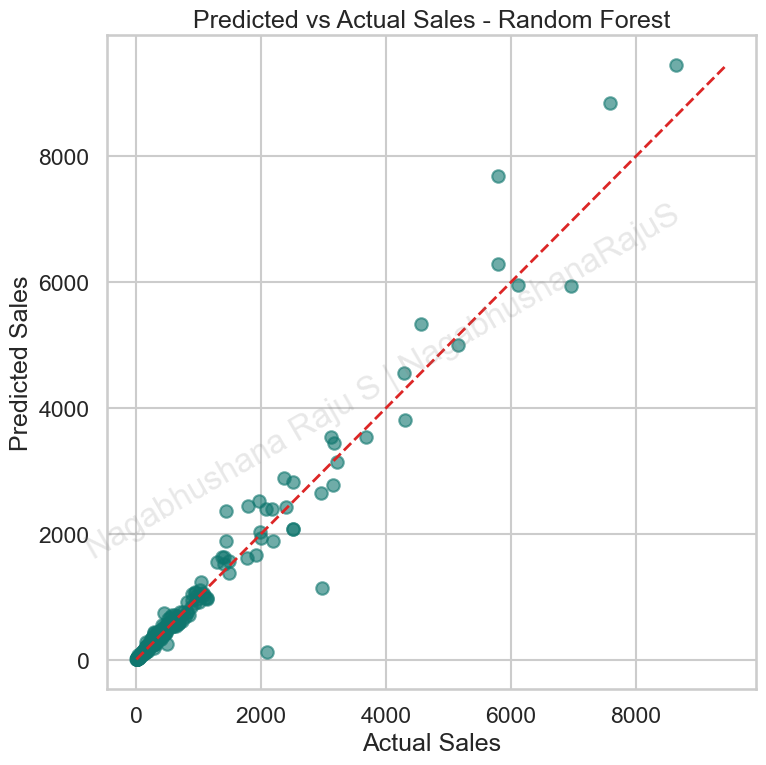

Saved model pipeline to: e:\NYERAS\outputs\models\retail_sales_pipeline.joblib
Saved report to: e:\NYERAS\outputs\phase1_notebook_report.md
                     metric                                        value
0      Rows before cleaning                                         1530
1       Rows after cleaning                                         1500
2        Duplicates removed                                           30
3  Missing values remaining                                            0
4            Dataset source               Synthetic fallback retail data
5                Best model                                Random Forest
6            Model artifact  outputs\models\retail_sales_pipeline.joblib
               model         mae         rmse        r2
2      Random Forest   94.071597   257.013131  0.954734
1  Linear Regression  279.089466   579.235972  0.770082
0    Baseline Median  577.840944  1308.642128 -0.173554


In [33]:
def dataframe_to_markdown(df: pd.DataFrame, max_rows: int = 10) -> str:
    preview = df.head(max_rows).copy()
    headers = [str(column) for column in preview.columns]
    lines = ["| " + " | ".join(headers) + " |", "| " + " | ".join(["---"] * len(headers)) + " |"]
    for row in preview.itertuples(index=False):
        values = [str(value) for value in row]
        lines.append("| " + " | ".join(values) + " |")
    return "\n".join(lines)


best_predictions = best_pipeline.predict(X_test)
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(y_test, best_predictions, alpha=0.6, color="#0f766e")
limits = [min(y_test.min(), best_predictions.min()), max(y_test.max(), best_predictions.max())]
ax.plot(limits, limits, linestyle="--", color="#dc2626", linewidth=2)
ax.set_xlabel("Actual Sales")
ax.set_ylabel("Predicted Sales")
ax.set_title(f"Predicted vs Actual Sales - {best_model_name}")
apply_matplotlib_signature(fig)
fig.tight_layout()
prediction_plot_path = PLOTS_DIR / "predicted_vs_actual.png"
fig.savefig(prediction_plot_path, dpi=300, bbox_inches="tight")
plt.show()

model_path = MODELS_DIR / "retail_sales_pipeline.joblib"
joblib.dump(best_pipeline, model_path)
print(f"Saved model pipeline to: {model_path}")

report_path = OUTPUT_DIR / "phase1_notebook_report.md"
cleaned_summary = pd.DataFrame(
    [
        {"metric": "Rows before cleaning", "value": len(retail_df)},
        {"metric": "Rows after cleaning", "value": len(cleaned_df)},
        {"metric": "Duplicates removed", "value": int(retail_df.duplicated().sum())},
        {"metric": "Missing values remaining", "value": int(cleaned_df.isna().sum().sum())},
        {"metric": "Dataset source", "value": source_label},
        {"metric": "Best model", "value": best_model_name},
        {"metric": "Model artifact", "value": str(model_path.relative_to(WORKSPACE_ROOT))},
    ]
)

monthly_trend = (
    cleaned_df.assign(month_period=cleaned_df["date"].dt.to_period("M"))
    .groupby("month_period")["sales"]
    .sum()
    .reset_index()
)

report_sections = [
    "# Retail Insights and Prediction Report",
    "",
    "## Dataset Overview",
    dataframe_to_markdown(cleaned_summary, max_rows=10),
    "",
    "## Model Comparison",
    dataframe_to_markdown(results_df, max_rows=10),
    "",
    "## Top Products",
    dataframe_to_markdown(cleaned_df.groupby("product", dropna=False)["sales"].sum().sort_values(ascending=False).head(10).reset_index(), max_rows=10),
    "",
    "## Top Regions",
    dataframe_to_markdown(cleaned_df.groupby("region", dropna=False)["sales"].sum().sort_values(ascending=False).head(10).reset_index(), max_rows=10),
    "",
    "## Seasonal Pattern",
    dataframe_to_markdown(monthly_trend, max_rows=12),
    "",
    "## Notes",
    f"- The best model on the holdout set was **{best_model_name}**.",
    f"- Predicted-vs-actual chart saved to `{prediction_plot_path.relative_to(WORKSPACE_ROOT)}`.",
    f"- Cleaned dataset saved to `{cleaned_path.relative_to(WORKSPACE_ROOT)}`.",
    f"- Visual attribution uses the signature marker `{SIGNATURE_BANNER}`.",
]
report_path.write_text("\n".join(report_sections), encoding="utf-8")
print(f"Saved report to: {report_path}")
print(cleaned_summary)
print(results_df)

## 11. Chat Bot Interface

This section adds a notebook-native chat panel. Use it to ask for sales predictions, model metrics, top products, top regions, or seasonality summaries without leaving Jupyter.

In [34]:
from html import escape

import re

import ipywidgets as widgets
from IPython.display import display


def _mode_value(series: pd.Series, default: str = "Unknown") -> str:
    mode = series.mode(dropna=True)
    return str(mode.iloc[0]) if not mode.empty else default


known_categories = sorted(cleaned_df["category"].dropna().astype(str).unique().tolist()) if "category" in cleaned_df.columns else []
known_regions = sorted(cleaned_df["region"].dropna().astype(str).unique().tolist()) if "region" in cleaned_df.columns else []
known_products = sorted(cleaned_df["product"].dropna().astype(str).unique().tolist()) if "product" in cleaned_df.columns else []

product_to_category = {}
product_to_price = {}
product_to_quantity = {}
if "product" in cleaned_df.columns:
    if "category" in cleaned_df.columns:
        product_to_category = cleaned_df.groupby("product")["category"].agg(lambda series: _mode_value(series, "Other")).to_dict()
    if "price" in cleaned_df.columns:
        product_to_price = cleaned_df.groupby("product")["price"].median().to_dict()
    if "quantity" in cleaned_df.columns:
        product_to_quantity = cleaned_df.groupby("product")["quantity"].median().to_dict()

if "date" in cleaned_df.columns:
    default_date = pd.to_datetime(cleaned_df["date"], errors="coerce").median()
    if pd.isna(default_date):
        default_date = pd.Timestamp.today().normalize()
else:
    default_date = pd.Timestamp.today().normalize()

feature_defaults = {}
for column in feature_columns:
    if column in numeric_features:
        feature_defaults[column] = float(cleaned_df[column].median())
    elif column in categorical_features:
        feature_defaults[column] = _mode_value(cleaned_df[column], "Unknown")
    else:
        feature_defaults[column] = 0

if "month" in feature_defaults:
    feature_defaults["month"] = int(default_date.month)
if "day_of_week" in feature_defaults:
    feature_defaults["day_of_week"] = int(default_date.dayofweek)
if "hour" in feature_defaults:
    feature_defaults["hour"] = int(default_date.hour)
if "is_weekend" in feature_defaults:
    feature_defaults["is_weekend"] = int(default_date.dayofweek >= 5)
if "customer_purchase_count" in feature_defaults:
    if "customer_purchase_count" in cleaned_df.columns:
        feature_defaults["customer_purchase_count"] = int(cleaned_df["customer_purchase_count"].median())
    else:
        feature_defaults["customer_purchase_count"] = 1


def _match_known_term(message: str, choices: list[str]) -> str | None:
    lowered = message.lower()
    matches = [choice for choice in choices if choice.lower() in lowered]
    return max(matches, key=len) if matches else None


def _extract_number(message: str, labels: list[str], default: float | int | None = None, as_int: bool = False):
    for label in labels:
        pattern = rf"(?:{re.escape(label).replace('\\ ', '\\s+')})\s*[:=]?\s*\$?(-?\d+(?:\.\d+)?)"
        match = re.search(pattern, message, flags=re.IGNORECASE)
        if match:
            value = float(match.group(1))
            return int(round(value)) if as_int else value
    return default


def build_prediction_frame(message: str) -> tuple[pd.DataFrame, list[str]]:
    features = feature_defaults.copy()
    notes: list[str] = []
    text = message.strip()

    explicit_product = _match_known_term(text, known_products)
    explicit_category = _match_known_term(text, known_categories)
    explicit_region = _match_known_term(text, known_regions)

    if explicit_product:
        notes.append(f"Detected product '{explicit_product}'.")
        if explicit_product in product_to_category and "category" in features:
            features["category"] = product_to_category[explicit_product]
        if explicit_product in product_to_price and "price" in features:
            features["price"] = float(product_to_price[explicit_product])
        if explicit_product in product_to_quantity and "quantity" in features:
            features["quantity"] = float(product_to_quantity[explicit_product])

    if explicit_category and "category" in features:
        features["category"] = explicit_category
    if explicit_region and "region" in features:
        features["region"] = explicit_region

    quantity_value = _extract_number(text, ["quantity", "qty", "units", "items"])
    if quantity_value is not None and "quantity" in features:
        features["quantity"] = float(quantity_value)

    price_value = _extract_number(text, ["price", "unit price", "selling price", "sale price"])
    if price_value is not None and "price" in features:
        features["price"] = float(price_value)

    customer_count_value = _extract_number(
        text,
        ["customer_purchase_count", "customer purchase count", "purchase count", "history count"],
        as_int=True,
    )
    if customer_count_value is not None and "customer_purchase_count" in features:
        features["customer_purchase_count"] = int(customer_count_value)

    hour_value = _extract_number(text, ["hour"], as_int=True)
    if hour_value is not None and "hour" in features:
        features["hour"] = int(hour_value)

    date_match = re.search(r"\b(20\d{2}-\d{2}-\d{2})\b", text)
    if date_match:
        parsed_date = pd.to_datetime(date_match.group(1), errors="coerce")
        if pd.notna(parsed_date):
            if "month" in features:
                features["month"] = int(parsed_date.month)
            if "day_of_week" in features:
                features["day_of_week"] = int(parsed_date.dayofweek)
            if "hour" in features:
                features["hour"] = int(parsed_date.hour)
            if "is_weekend" in features:
                features["is_weekend"] = int(parsed_date.dayofweek >= 5)
            notes.append(f"Used date {parsed_date.date()} to derive time features.")
    elif "date" in text.lower():
        notes.append("No parseable YYYY-MM-DD date was found, so default time features were used.")

    prediction_frame = pd.DataFrame([features])[feature_columns]
    return prediction_frame, notes


def summarize_model_results() -> str:
    formatted = results_df.copy()
    for column in [column for column in ["mae", "rmse", "r2"] if column in formatted.columns]:
        formatted[column] = formatted[column].map(lambda value: f"{value:,.2f}")
    return f"Best model: {best_model_name}\n\n{formatted.to_string(index=False)}"


def summarize_retail_table(df: pd.DataFrame, group_column: str, title: str, value_column: str = "sales", rows: int = 5) -> str:
    if group_column not in df.columns or value_column not in df.columns:
        return f"{title} is not available in this dataset."
    summary_table = df.groupby(group_column, dropna=False)[value_column].sum().sort_values(ascending=False).head(rows).reset_index()
    if summary_table.empty:
        return f"{title} is not available in this dataset."
    summary_table[value_column] = summary_table[value_column].map(lambda value: f"{value:,.2f}")
    return f"{title}\n\n{summary_table.to_string(index=False)}"


def answer_chat_message(message: str) -> str:
    normalized = message.strip().lower()
    if not normalized:
        return "Type a question or a prediction request."

    if any(keyword in normalized for keyword in ["help", "how do i", "examples", "what can you do"]):
        return (
            "Ask me for a prediction using quantity, price, category, region, and date.\n"
            "Examples:\n"
            "- Predict sales for quantity 3 price 120 category Electronics region West date 2025-04-01\n"
            "- Estimate sales for product Laptop in East region\n"
            "- Show model metrics\n"
            "- What are the top products?"
        )

    if any(keyword in normalized for keyword in ["metric", "metrics", "score", "r2", "mae", "rmse", "best model", "model comparison"]):
        return summarize_model_results()

    if any(keyword in normalized for keyword in ["top product", "top products", "best product"]):
        return summarize_retail_table(cleaned_df, "product", "Top Products")
    if any(keyword in normalized for keyword in ["top region", "best region", "regions"]):
        return summarize_retail_table(cleaned_df, "region", "Top Regions")
    if any(keyword in normalized for keyword in ["season", "monthly", "trend", "sales over time"]):
        if "date" in cleaned_df.columns:
            seasonal = cleaned_df.assign(month_period=cleaned_df["date"].dt.to_period("M")).groupby("month_period")["sales"].sum().reset_index()
            seasonal["sales"] = seasonal["sales"].map(lambda value: f"{value:,.2f}")
            return f"Seasonality snapshot\n\n{seasonal.head(12).to_string(index=False)}"
        return "No date column is available for seasonality analysis."

    prediction_frame, notes = build_prediction_frame(message)
    predicted_sales = float(best_pipeline.predict(prediction_frame)[0])
    feature_preview = prediction_frame.iloc[0].to_string()
    notes_text = "\n".join(f"- {note}" for note in notes) if notes else "- Used dataset defaults for any missing inputs."
    return (
        f"Predicted sales: ${predicted_sales:,.2f}\n\n"
        f"Model: {best_model_name}\n\n"
        f"Inputs used:\n{feature_preview}\n\n"
        f"Notes:\n{notes_text}\n\n"
        "If you want a different scenario, change quantity, price, category, region, or date."
    )


chat_title = widgets.HTML("<h3 style='margin:0;'>Retail Model Chat</h3><p style='margin-top:4px;'>Ask for a sales prediction or model insight. Use plain language or key=value prompts.</p>")
welcome_box = widgets.HTML(f"<div style='padding:12px;border-left:4px solid #0f766e;background:#f8fafc;'>You are chatting with the trained <strong>{best_model_name}</strong> sales model.</div>")
chat_log = widgets.VBox(layout=widgets.Layout(width="100%"))
user_input = widgets.Textarea(
    placeholder="Example: Predict sales for quantity=3 price=120 category=Electronics region=West date=2025-04-01",
    layout=widgets.Layout(width="100%", height="90px"),
)
send_button = widgets.Button(description="Send", button_style="primary", icon="paper-plane")
clear_button = widgets.Button(description="Clear", icon="trash")


def add_chat_bubble(role: str, text: str, is_user: bool = False) -> None:
    background = "#0f766e" if is_user else "#f8fafc"
    border = "#0f766e" if is_user else "#cbd5e1"
    color = "#ffffff" if is_user else "#111827"
    alignment = "flex-end" if is_user else "flex-start"
    bubble = widgets.HTML(
        value=(
            f"<div style='display:flex; justify-content:{alignment}; margin:6px 0;'>"
            f"<div style='max-width:85%; padding:12px 14px; border-radius:14px; background:{background}; "
            f"border:1px solid {border}; color:{color}; white-space:pre-wrap;'>"
            f"<div style='font-size:12px; font-weight:700; margin-bottom:4px;'>{escape(role)}</div>"
            f"{escape(text)}"
            "</div></div>"
        )
    )
    chat_log.children = tuple(chat_log.children) + (bubble,)


def on_send_clicked(button) -> None:
    _ = button
    message = user_input.value.strip()
    if not message:
        return
    add_chat_bubble("You", message, is_user=True)
    response = answer_chat_message(message)
    add_chat_bubble(best_model_name, response, is_user=False)
    user_input.value = ""


def on_clear_clicked(button) -> None:
    _ = button
    chat_log.children = ()
    add_chat_bubble(
        best_model_name,
        "Chat cleared. Ask me for a sales prediction, model metrics, top products, top regions, or seasonality summaries.",
        is_user=False,
    )


send_button.on_click(on_send_clicked)
clear_button.on_click(on_clear_clicked)

add_chat_bubble(
    best_model_name,
    "Start with a request like:\n- Predict sales for quantity 3 price 120 category Electronics region West date 2025-04-01\n- Show model metrics\n- What are the top products?",
    is_user=False,
)

display(widgets.VBox([chat_title, welcome_box, chat_log, user_input, widgets.HBox([send_button, clear_button])]))

## 12. Multicolor and Interactive 3D Plots

This section adds richer Plotly visuals, including multicolor retail charts and a dropdown-driven 3D explorer with changeable axes and color grouping.

In [22]:
# Signature: Nagabhushana Raju S
import ipywidgets as widgets
import plotly.express as px
from IPython.display import clear_output, display

interactive_plot_dir = PLOTS_DIR / "interactive"
interactive_plot_dir.mkdir(parents=True, exist_ok=True)

plotly_numeric_columns = [
    column
    for column in ["quantity", "price", "sales", "customer_purchase_count", "month", "day_of_week", "hour"]
    if column in cleaned_df.columns
]
plotly_categorical_columns = [column for column in ["category", "region", "product"] if column in cleaned_df.columns]

if "category" in cleaned_df.columns and {"quantity", "sales", "price"}.issubset(cleaned_df.columns):
    scatter_fig = px.scatter(
        cleaned_df,
        x="quantity",
        y="sales",
        color="category",
        size="price",
        hover_data=[column for column in ["product", "region", "customer_id"] if column in cleaned_df.columns],
        color_discrete_sequence=px.colors.qualitative.Bold,
        template="plotly_white",
        title="Multicolor Sales Explorer",
    )
    scatter_fig.update_traces(marker=dict(opacity=0.85, line=dict(width=0.5, color="white")))
    scatter_fig = apply_plotly_signature(scatter_fig)
    scatter_fig.write_html(interactive_plot_dir / "multicolor_sales_explorer.html", include_plotlyjs="cdn")
    scatter_fig.show()


def build_3d_retail_figure(x_axis: str, y_axis: str, z_axis: str, color_by: str):
    color_argument = None if color_by == "None" else color_by
    fig = px.scatter_3d(
        cleaned_df,
        x=x_axis,
        y=y_axis,
        z=z_axis,
        color=color_argument,
        hover_data=[column for column in ["product", "region", "category", "customer_id"] if column in cleaned_df.columns],
        color_discrete_sequence=px.colors.qualitative.Vivid,
        template="plotly_white",
        title=f"Interactive 3D Retail Explorer: {x_axis} vs {y_axis} vs {z_axis}",
    )
    fig.update_traces(marker=dict(size=5, opacity=0.82))
    fig.update_layout(
        scene=dict(
            xaxis_title=x_axis.title(),
            yaxis_title=y_axis.title(),
            zaxis_title=z_axis.title(),
            bgcolor="rgb(250,250,250)",
        ),
        margin=dict(l=0, r=0, t=60, b=0),
    )
    fig = apply_plotly_signature(fig)
    fig.write_html(interactive_plot_dir / "interactive_3d_retail.html", include_plotlyjs="cdn")
    return fig


if len(plotly_numeric_columns) >= 3:
    x_default = "quantity" if "quantity" in plotly_numeric_columns else plotly_numeric_columns[0]
    y_default = "price" if "price" in plotly_numeric_columns else plotly_numeric_columns[1]
    z_default = "sales" if "sales" in plotly_numeric_columns else plotly_numeric_columns[2]
    color_default = "category" if "category" in plotly_categorical_columns else (plotly_categorical_columns[0] if plotly_categorical_columns else "None")

    x_dropdown = widgets.Dropdown(options=plotly_numeric_columns, value=x_default, description="X")
    y_dropdown = widgets.Dropdown(options=plotly_numeric_columns, value=y_default, description="Y")
    z_dropdown = widgets.Dropdown(options=plotly_numeric_columns, value=z_default, description="Z")
    color_dropdown = widgets.Dropdown(options=["None", *plotly_categorical_columns], value=color_default, description="Color")
    refresh_button = widgets.Button(description="Update 3D Plot", button_style="success", icon="refresh")
    plot_output = widgets.Output()

    def refresh_3d_plot(button=None) -> None:
        _ = button
        with plot_output:
            clear_output(wait=True)
            display(build_3d_retail_figure(x_dropdown.value, y_dropdown.value, z_dropdown.value, color_dropdown.value))

    refresh_button.on_click(refresh_3d_plot)
    control_row = widgets.HBox([x_dropdown, y_dropdown, z_dropdown, color_dropdown, refresh_button])
    display(widgets.HTML("<p><strong>Interactive 3D Explorer:</strong> change the axes or color grouping, then click Update 3D Plot.</p>"))
    display(control_row, plot_output)
    refresh_3d_plot()
else:
    print("Not enough numeric columns are available to build the interactive 3D explorer.")

HTML(value='<p><strong>Interactive 3D Explorer:</strong> change the axes or color grouping, then click Update …

Output()